<a href="https://colab.research.google.com/github/jasminjahanpuspo/Bengali_Taka/blob/main/BT/BT_EfficientNet_CBAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**<font color='yellow'>Model Name: EfficientNet_Attention_Mechanism</font>**


# Step 1: Setup Environment

##### 🔹 Mount Google Drive
*   Access datasets stored in your Google Drive.  
*   After running this cell, you'll be prompted to authorize access.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### 🔹 Import Required Libraries
*   Load all necessary libraries for image processing, data handling, and visualization.
*   Load TensorFlow, Keras, and layers for building CNN models.

In [2]:
# ============================================================
#  Libraries for Data Handling
# ============================================================
import os                      # File and directory operations
import glob as gb              # File pattern matching (e.g., get all image paths)
import numpy as np             # Numerical operations and arrays
import pandas as pd            # Data manipulation and analysis

# ============================================================
#  Libraries for Image Processing
# ============================================================
import cv2                     # OpenCV for image reading and preprocessing
from PIL import Image          # Image loading and manipulation

# ============================================================
#  Libraries for Visualization
# ============================================================
import matplotlib.pyplot as plt # Plotting graphs and images
import seaborn as sns           # Advanced visualizations (e.g., heatmaps)
%matplotlib inline
import matplotlib

# ============================================================
#  Utilities and Helpers
# ============================================================
import random                  # For random sampling and augmentations
import math                    # Mathematical operations
import time                    # Measure training time and performance


In [3]:
# ============================================================
# TensorFlow & Keras Core Libraries
# ============================================================
import tensorflow as tf                       # Core TensorFlow library
from tensorflow import keras                  # High-level API for deep learning
from tensorflow.keras import layers, models   # Layers and model-building utilities

# ============================================================
# Dataset Utilities
# ============================================================
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Load and preprocess image datasets from directory structures

# ============================================================
# Layers for CNN Architectures
# ============================================================
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten,
    Conv2D, MaxPool2D, LeakyReLU
)


# Step 2: Prepare Dataset

##### 🔹 Create TensorFlow Datasets


*   Load images from the directories into TensorFlow datasets for training, validation, and testing.  
*   You can adjust `image_size` and `batch_size` as needed.



In [4]:
## Define the directories for training, testing, and validation
train_directory = '/content/drive/MyDrive/Bengali_Taka/BTP/BT/aug_train'
test_directory = '/content/drive/MyDrive/Bengali_Taka/BTP/BT/split/test'
valid_directory = '/content/drive/MyDrive/Bengali_Taka/BTP/BT/split/val'

In [5]:
IMG_SIZE = (224, 224)  # define resolution (299,299) /(224,224)
BATCH_SIZE = 128       # varies from dataset to datset prefferable 128/68/32

In [6]:
# Create TensorFlow datasets for training, testing, and validation
#you can customize parameters as per dataset
train_dataset = image_dataset_from_directory(
    train_directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb',
    seed=42
)

test_dataset = image_dataset_from_directory(
    test_directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb',
    seed=42
)

valid_dataset = image_dataset_from_directory(
    valid_directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb',
    seed=42
)

Found 1554 files belonging to 6 classes.
Found 120 files belonging to 6 classes.
Found 109 files belonging to 6 classes.


In [7]:
# Automatically detect number of classes from dataset
class_names = train_dataset.class_names  # works with image_dataset_from_directory
n_classes = len(class_names)

print("Detected Classes:", class_names)
print("Number of Classes:", n_classes)

Detected Classes: ['10 ', '100', '1000 ', '20 ', '50 ', '500']
Number of Classes: 6


In [ ]:
class_counts = []
for i in range(len(train_dataset.class_names)):
    class_counts.append(sum(1 for _, label in train_dataset.unbatch().as_numpy_iterator() if label == i))

Dataset = class_counts  # now your class weights will adapt automatically

#**<font color='red'>EfficientNet + CBAM (Convolutional Block Attention Module)</font>**


## Step 3.1: Model Training

##### 🔗 CNN with CBAM
Add **CBAM (Convolutional Block Attention Module)** on top of a CNN backbone to enhance feature representation with **channel and spatial attention**.


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# CBAM Implementation in Keras
# -----------------------------
class ChannelAttention(layers.Layer):
    def __init__(self, channels, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = layers.GlobalAveragePooling2D()
        self.max_pool = layers.GlobalMaxPooling2D()

        self.fc1 = layers.Dense(channels // ratio, activation="relu", kernel_initializer='he_normal', use_bias=True)
        self.fc2 = layers.Dense(channels, kernel_initializer='he_normal', use_bias=True)

    def call(self, inputs):
        avg_out = self.fc2(self.fc1(self.avg_pool(inputs)))
        max_out = self.fc2(self.fc1(self.max_pool(inputs)))
        out = avg_out + max_out
        out = tf.nn.sigmoid(out)
        out = tf.reshape(out, [-1, 1, 1, inputs.shape[-1]])
        return inputs * out


class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = layers.Conv2D(1, kernel_size, padding="same", activation="sigmoid", kernel_initializer='he_normal')

    def call(self, inputs):
        avg_out = tf.reduce_mean(inputs, axis=3, keepdims=True)
        max_out = tf.reduce_max(inputs, axis=3, keepdims=True)
        concat = tf.concat([avg_out, max_out], axis=3)
        return inputs * self.conv1(concat)


class CBAM(layers.Layer):
    def __init__(self, channels, ratio=8, kernel_size=7, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.channel_attention = ChannelAttention(channels, ratio)
        self.spatial_attention = SpatialAttention(kernel_size)

    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x


# -----------------------------
# EfficientNetB0 + CBAM Model
# -----------------------------
def create_model(image_shape=(224,224,3), num_classes=2):
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=image_shape,
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = True
    for layer in base_model.layers[:200]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=image_shape)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x, training=False)   # Output: (None, 7, 7, 1280) for EfficientNetB0

    # 🔥 Add CBAM
    x = CBAM(channels=1280, name="cbam")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model


##### 🔹 Instantiate the model
*   Initialize the full model with custom layers.

In [9]:
# -----------------------------
base_learning_rate = 0.0001
model = create_model(image_shape=(224,224,3), num_classes=n_classes)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##### 🔹 Build and Compile Model

In [10]:
# -----------------------------
# Build and Compile
model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])


##### 🔹 Model Visualization

* Display the model structure in both graphical and tabular formats to verify architecture before training.

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam (CBAM)                     │ (None, 7, 7, 1280)     │       411,139 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,468,396 (17.05 MB)

 Trainable params: 2,469,529 (9.42 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

In [ ]:
# Import the plot_model function from Keras
from tensorflow.keras.utils import plot_model

# Plot and save the model architecture as a PNG image
plot_model(
    model,                      # Your Keras model
    to_file='model_architecture.png',  # File name for saving the image
    show_shapes=True,           # Display input/output shapes for each layer
    show_layer_names=True,      # Display layer names
    dpi=80                      # Set resolution (smaller DPI → smaller image)
)


##### 🔹 Load / Set Model Weights
Load pre-trained weights or initialize custom weights for the CNN + CBAM model.


In [12]:
# Number of classes
num_classes = n_classes

# All classes are equal → class weight = 1 for all
class_weight = {i: 1.0 for i in range(num_classes)}

print(class_weight)


{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}


##### 🔹 Model Checkpoint & Save
Save the best model during training using **checkpoints**, and optionally save the final trained model.


In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint

model_filepath="/content/drive/MyDrive/Bengali_Taka/BTP/BTP_A_M/effcientnet_cbam.keras"
checkpoint = ModelCheckpoint(
    filepath=model_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if val_accuracy doesn't improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',   # which metric to monitor
    patience=5,               # number of epochs with no improvement to wait
    restore_best_weights=True, # restore the best model after stopping
    verbose=1
)

##### 🔹 Train the Model
Train the CNN + CBAM model using the training dataset, validate on the validation dataset, and store the training history.


In [15]:
# Start timer before training
start_time = time.time()

# Train the model
## change hyperparameter such as epoches
# Then add it to your existing callbacks list
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=15,
    class_weight=class_weight,
    verbose=2,
    callbacks=[checkpoint, early_stop]  # add early_stop alongside checkpoint
)

# End timer
end_time = time.time()

# Calculate training duration in minutes
training_time_mins = (end_time - start_time) / 60

print(f"🕒 Total Training Time: {training_time_mins:.2f} minutes")

Epoch 1/15

Epoch 1: val_accuracy improved from -inf to 0.39450, saving model to /content/drive/MyDrive/Bengali_Taka/BTP/BTP_A_M/effcientnet_cbam.keras
13/13 - 327s - 25s/step - accuracy: 0.3816 - loss: 1.6823 - val_accuracy: 0.3945 - val_loss: 1.6904
Epoch 2/15

Epoch 2: val_accuracy improved from 0.39450 to 0.63303, saving model to /content/drive/MyDrive/Bengali_Taka/BTP/BTP_A_M/effcientnet_cbam.keras
13/13 - 105s - 8s/step - accuracy: 0.7111 - loss: 1.4499 - val_accuracy: 0.6330 - val_loss: 1.5549
Epoch 3/15

Epoch 3: val_accuracy improved from 0.63303 to 0.77064, saving model to /content/drive/MyDrive/Bengali_Taka/BTP/BTP_A_M/effcientnet_cbam.keras
13/13 - 91s - 7s/step - accuracy: 0.8990 - loss: 1.1505 - val_accuracy: 0.7706 - val_loss: 1.3470
Epoch 4/15

Epoch 4: val_accuracy improved from 0.77064 to 0.82569, saving model to /content/drive/MyDrive/Bengali_Taka/BTP/BTP_A_M/effcientnet_cbam.keras
13/13 - 89s - 7s/step - accuracy: 0.9569 - loss: 0.8487 - val_accuracy: 0.8257 - val_l

##### 🔹 Test the Model
Evaluate the trained model on the test dataset.

In [16]:
model.evaluate(test_dataset , verbose = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step - accuracy: 0.9917 - loss: 0.3752


[0.3752148747444153, 0.9916666746139526]

## Step 4.1: Results & Visualizations


##### 🔹 Actual vs Predicted Classes

*  Visualize the model’s predictions compared to true labels on the test dataset.
*   Collect **one example per class** from `test_dataset`.




1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


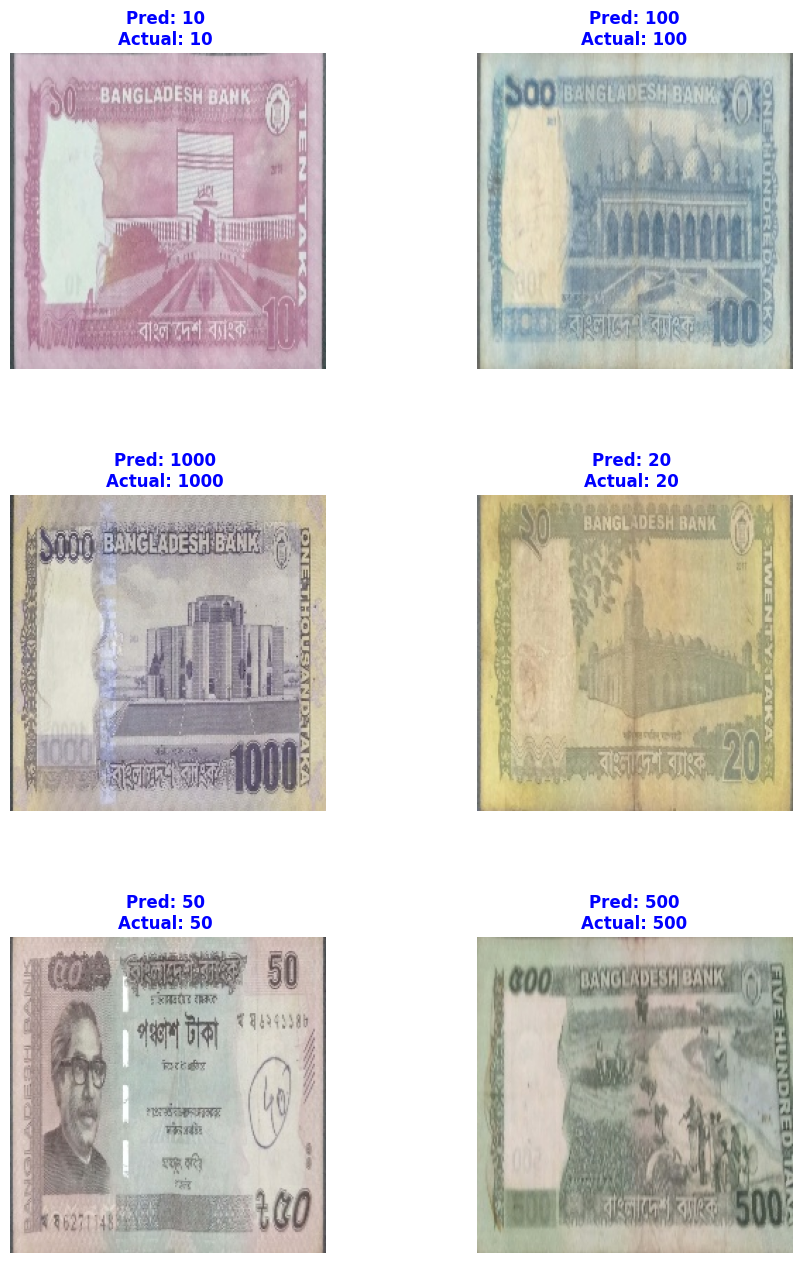

In [17]:
examples = {}
for images, labels in test_dataset.unbatch().take(1000):  # take enough to find all classes
    class_idx = labels.numpy()
    if class_idx not in examples:
        examples[class_idx] = images
    if len(examples) == n_classes:
        break

# Plotting
cols = 2  # number of columns
rows = math.ceil(n_classes / cols)
plt.figure(figsize=(cols * 5, rows * 5))

for i, class_idx in enumerate(sorted(examples.keys())):
    img = examples[class_idx].numpy().astype("uint8")
    img_exp = tf.expand_dims(img, 0)  # expand batch dim
    predict = model.predict(img_exp)
    predicted = class_names[np.argmax(predict)]
    actual = class_names[class_idx]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    color = 'blue' if predicted == actual else 'red'
    plt.title(f"Pred: {predicted}\nActual: {actual}", fontsize=12, fontweight='bold', color=color)
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9,
                        top=0.9, wspace=0.4, hspace=0.4)

plt.show()

##### 🔹 Actual vs Predicted Images

*   Display sample images from the test set with their **true labels and model predictions** for qualitative evaluation.
*   Show **three images per class** for qualitative evaluation.


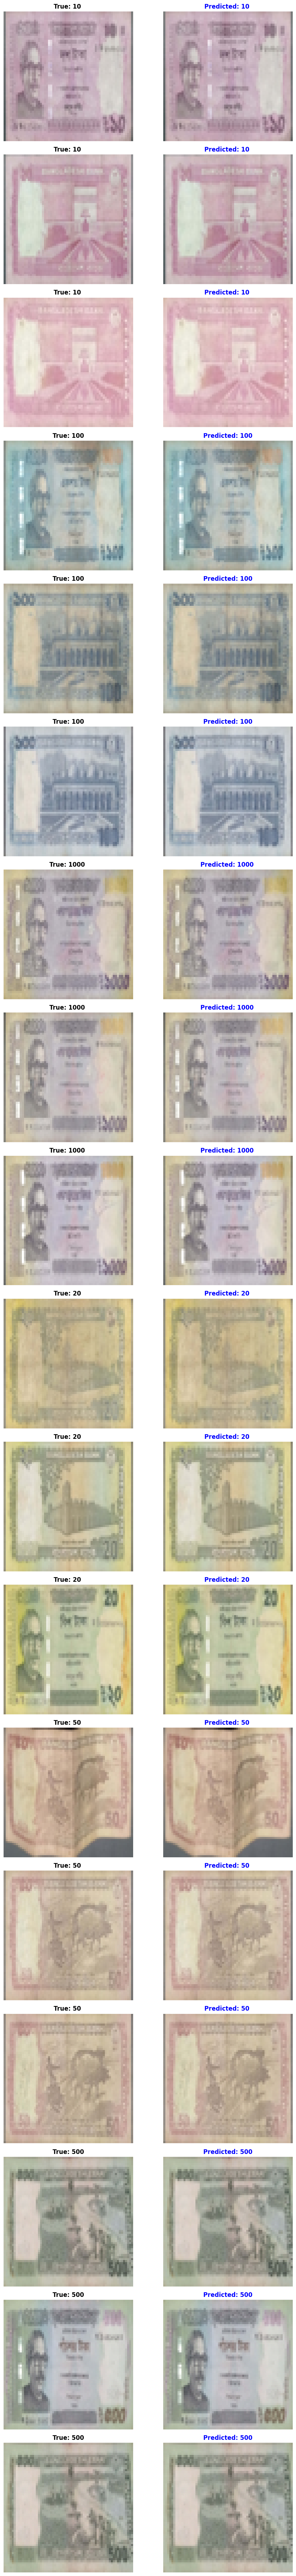

In [18]:
# Function to load multiple random images per class
def load_images_per_class(folder, num_images_per_class=3):
    images = []
    labels = []
    class_names = []

    for class_idx, subfolder in enumerate(sorted(os.listdir(folder))):
        subfolder_path = os.path.join(folder, subfolder)
        if os.path.isdir(subfolder_path):
            class_names.append(subfolder)
            image_files = os.listdir(subfolder_path)
            selected_files = random.sample(image_files, min(num_images_per_class, len(image_files)))
            for image_file in selected_files:
                img_path = os.path.join(subfolder_path, image_file)
                img = Image.open(img_path).convert('RGB')
                img = img.resize((64, 64))
                images.append(np.array(img)/255.0)
                labels.append(class_idx)

    return np.array(images), np.array(labels), class_names

# Path to your test folder
test_folder = test_directory

# Load images: change num_images_per_class as needed
num_images_per_class = 3
images, labels, class_names = load_images_per_class(test_folder, num_images_per_class=num_images_per_class)

# Example predicted labels (replace with your model predictions)
predicted_labels = labels.copy()  # For demo, assume correct predictions

# Automatically calculate subplot grid
total_images = len(images)
cols = 2  # Original + Predicted
rows = total_images  # Each image gets a row

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))

if rows == 1:  # Special case if only 1 image
    axes = np.expand_dims(axes, axis=0)

for i in range(total_images):
    img = images[i]
    true_label = class_names[labels[i]]
    predicted_label = class_names[predicted_labels[i]]

    # Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'True: {true_label}', fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')

    # Predicted
    axes[i, 1].imshow(img)
    color = 'blue' if true_label == predicted_label else 'red'
    axes[i, 1].set_title(f'Predicted: {predicted_label}', fontsize=12, fontweight='bold', color=color)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


##### 🔹 Label Binarization & Classification Metrics
Binarize class labels and evaluate model performance using metrics like **accuracy, precision, recall, and F1-score**.


In [19]:
from sklearn.preprocessing import label_binarize

# Initialize empty lists to store true labels and predicted labels
true_labels = []
predicted_labels = []

# Iterate through the validation dataset and make predictions
for images, labels in test_dataset:
    predictions = model.predict(images)
    predicted_labels.extend(np.argmax(predictions, axis=1))
    true_labels.extend(labels.numpy())

# Binarize the true and predicted labels
true_labels_bin = label_binarize(true_labels, classes=np.unique(true_labels))
predicted_labels_bin = label_binarize(predicted_labels, classes=np.unique(predicted_labels))

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


##### 🔹 Classification Report

Provides precision, recall, F1-score, and support for each class to summarize model performance.


In [20]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)

# Print the classification report
print(report)

              precision    recall  f1-score   support

         10        0.96      1.00      0.98        22
         100       1.00      1.00      1.00        20
       1000        1.00      1.00      1.00        20
         20        1.00      1.00      1.00        21
         50        1.00      0.94      0.97        18
         500       1.00      1.00      1.00        19

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



##### 🔹 Confusion Matrix
Visualize the **confusion matrix** to assess class-wise prediction performance.

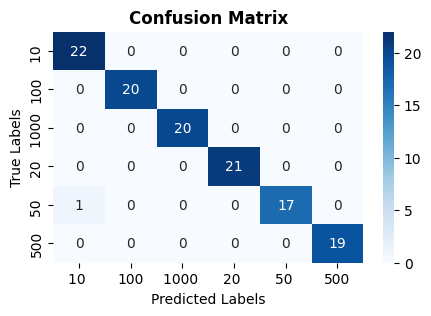

In [21]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix', fontweight='bold')
plt.show()

##### 📈 Training Accuracy & Loss
Visualize the model's **training and validation accuracy and loss** over epochs to assess learning and overfitting.

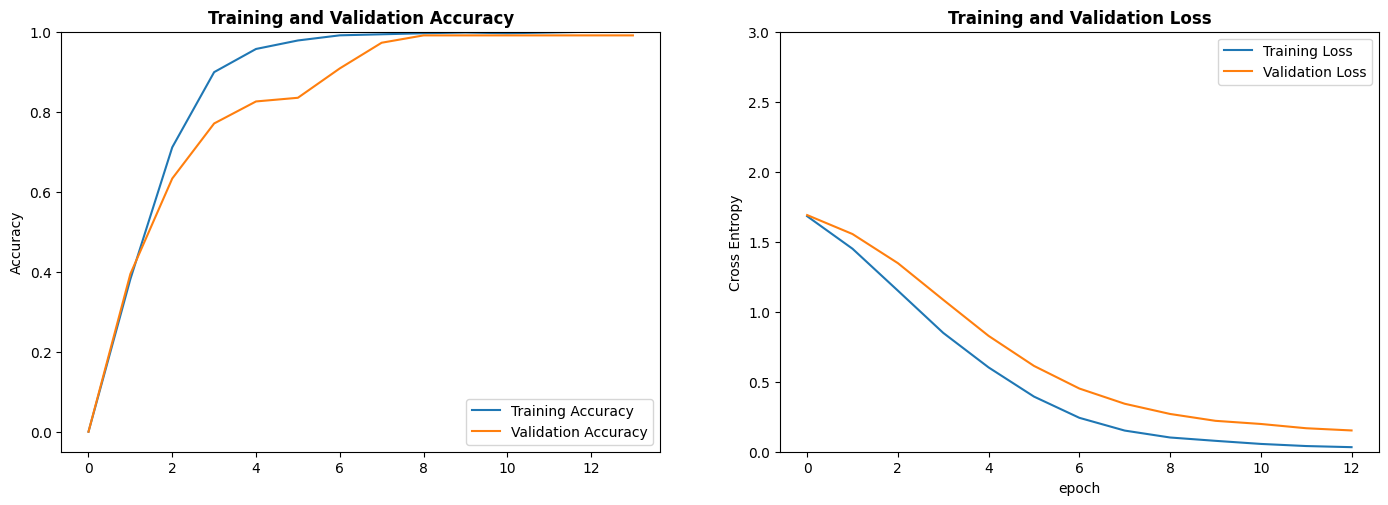

In [22]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(17, 12))
plt.subplot(2, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy', fontweight='bold')

plt.subplot(2, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,3.0])
plt.title('Training and Validation Loss', fontweight='bold')
plt.xlabel('epoch')
plt.show()

##### 📈 ROC curve
*   Plot the **ROC curve** to evaluate model performance.
*  **One-vs-Rest** for multiclass and
 **One-vs-One** for binary classification.

In [23]:
from sklearn.metrics import roc_curve, auc

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:     # or valid_dataset if you want
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Shape of predictions:", y_pred.shape)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Shape of predictions: (120, 6)


In [24]:
# Binarize labels for multiclass ROC
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

In [25]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


/tmp/ipython-input-860881180.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', n_classes)  # 'tab20' or 'tab10', n_classes colors


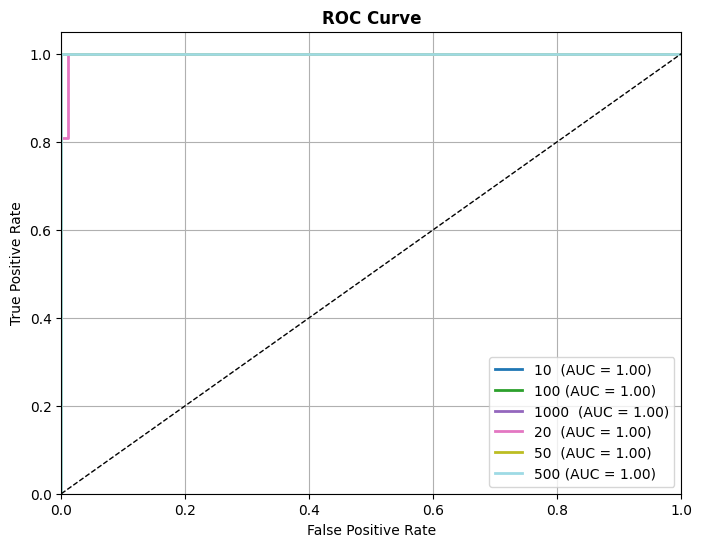

In [26]:
import matplotlib.cm as cm

plt.figure(figsize=(8, 6))

# Automatically generate colors
colors = cm.get_cmap('tab20', n_classes)  # 'tab20' or 'tab10', n_classes colors

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


##### 🔹 Cohen's Kappa
Measure agreement between predicted and true labels beyond chance.

In [27]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(true_labels, predicted_labels)
print(f'Cohen\'s Kappa: {kappa:.4f}')

Cohen's Kappa: 0.9900


##### 🔹 Matthews Correlation Coefficient (MCC)
Assess overall classification quality considering all confusion matrix terms.

In [28]:
from sklearn.metrics import matthews_corrcoef

# Assuming true_labels and predicted_labels are multiclass labels
mcc_values = [matthews_corrcoef(true_labels == i, predicted_labels == i) for i in np.unique(true_labels)]

average_mcc = np.mean(mcc_values)
print(f'Average Matthews Correlation Coefficient for Multiclass: {average_mcc:.4f}')

Average Matthews Correlation Coefficient for Multiclass: 0.9900


##### 🔹 Right vs Wrong Classifier
Visualize and analyze **correctly and incorrectly classified samples** to understand model performance.

In [29]:
# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Calculate total right and wrong predictions
total_right = sum(1 for true, pred in zip(true_labels, predicted_labels) if true == pred)
total_wrong = sum(1 for true, pred in zip(true_labels, predicted_labels) if true != pred)
total_samples = len(true_labels)

print("Total Right Predictions:", total_right)
print("Total Wrong Predictions:", total_wrong)

# Calculate percentages
right_percentage = (total_right / total_samples) * 100
wrong_percentage = (total_wrong / total_samples) * 100

# Data for the bar plot
labels = ['Right', 'Wrong']
percentages = [right_percentage, wrong_percentage]

Total Right Predictions: 119
Total Wrong Predictions: 1


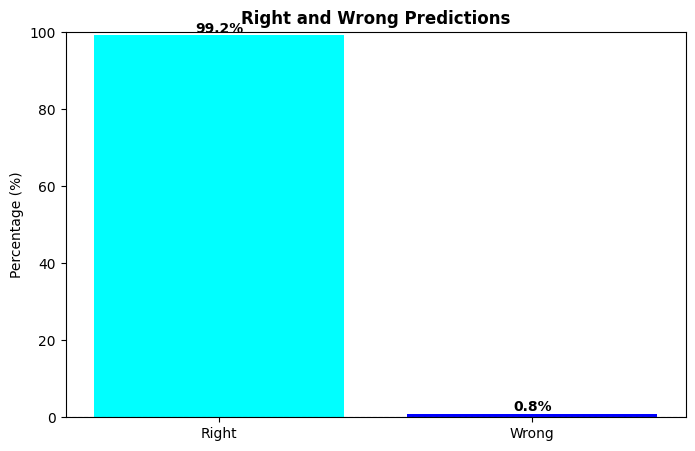

In [30]:
# Create the bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, percentages, color=['cyan', 'blue'])

# Add percentage labels above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}%',
             ha='center', fontweight='bold', va='bottom')  # va: vertical alignment

# Add titles and labels
plt.title('Right and Wrong Predictions', fontweight='bold')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)  # Set y-axis limit to 100%
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')  # Optional: Add a horizontal line at y=0

# Show the plot
plt.show()

##### 🔹 Sensitivity & Specificity
Evaluate each class's **sensitivity (recall)** and **specificity** based on true positives and true negatives


Overall Sensitivity (Recall): 0.991
Overall Specificity: 0.998


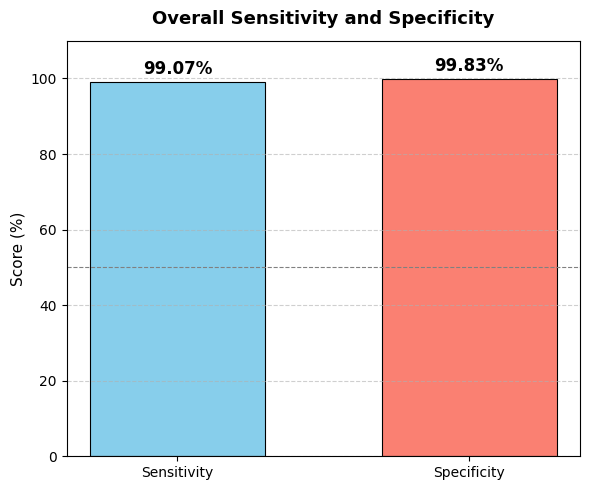

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Compute Sensitivity & Specificity ---
cm = confusion_matrix(true_labels, predicted_labels)
n_classes = cm.shape[0]

# Sensitivity (macro average): TP / (TP + FN)
sensitivity_per_class = np.diag(cm) / np.sum(cm, axis=1)
sensitivity = np.nanmean(sensitivity_per_class)

# Specificity (macro average): TN / (TN + FP)
specificity_list = []
for i in range(n_classes):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(np.delete(cm, i, axis=0)[:, i])
    specificity_list.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
specificity = np.nanmean(specificity_list)

print(f"Overall Sensitivity (Recall): {sensitivity:.3f}")
print(f"Overall Specificity: {specificity:.3f}")

# --- Plotting ---
metrics = ['Sensitivity', 'Specificity']
values = [sensitivity * 100, specificity * 100]  # Convert to percentage

plt.figure(figsize=(6, 5))
bars = plt.bar(metrics, values,
               color=['skyblue', 'salmon'],
               width=0.6, edgecolor='black', linewidth=0.8)

# Add percentage labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.0, f'{yval:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Overall Sensitivity and Specificity', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Score (%)', fontsize=11)
plt.ylim(0, 110)  # Add headroom for labels
plt.axhline(y=50, color='grey', linestyle='--', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##### 🔹 Jaccard Index & Dice Score
* Measure overlap between predicted and true classes using **Jaccard Index (IoU)** and **Dice Score**.


Overall Jaccard Index: 0.983
Overall Dice Score: 0.992


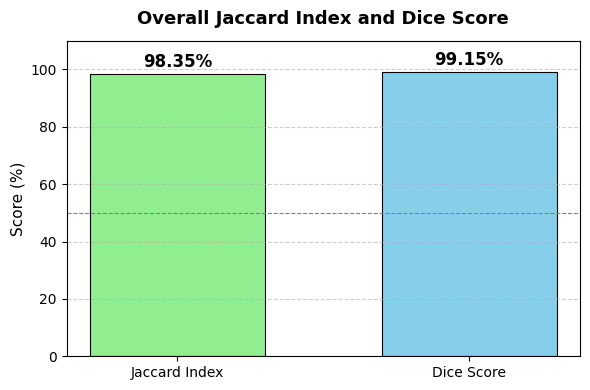

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Compute confusion matrix and scores ---
cm = confusion_matrix(true_labels, predicted_labels)
n_classes = cm.shape[0]

jaccard_per_class = []
dice_per_class = []

for i in range(n_classes):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp

    # Jaccard Index
    jaccard = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else np.nan
    jaccard_per_class.append(jaccard)

    # Dice Score
    dice = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else np.nan
    dice_per_class.append(dice)

# Macro-average (overall)
jaccard_index = np.nanmean(jaccard_per_class)
dice_score = np.nanmean(dice_per_class)

print(f"Overall Jaccard Index: {jaccard_index:.3f}")
print(f"Overall Dice Score: {dice_score:.3f}")

# --- Plotting ---
metrics = ['Jaccard Index', 'Dice Score']
values = [jaccard_index * 100, dice_score * 100]  # convert to %

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, values,
               color=['lightgreen', 'skyblue'],
               width=0.6, edgecolor='black', linewidth=0.8)

# Add percentage labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.0, f'{yval:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Overall Jaccard Index and Dice Score', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Score (%)', fontsize=11)
plt.ylim(0, 110)  # headroom for labels
plt.axhline(y=50, color='grey', linestyle='--', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##### 🔹 Model Evaluation Metrics
Summarize the model's performance using multiple metrics: **Accuracy**, **Precision**, **Recall (Sensitivity)**, **F1 Score**, **Negative Predictive Value (NPV)**, **AUC-ROC**

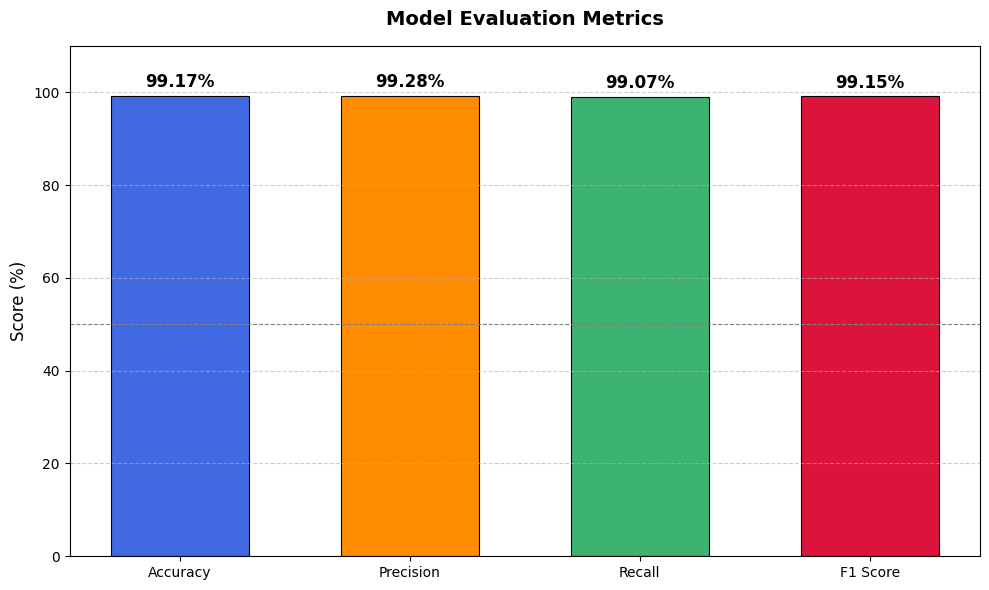

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ----- Metric Computation -----
n_classes = len(np.unique(true_labels))

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')
f1 = f1_score(true_labels, predicted_labels, average='macro')

# Binary: compute NPV and AUC
if n_classes == 2:
    cm = confusion_matrix(true_labels, predicted_labels)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc = roc_auc_score(true_labels, predicted_labels)
else:
    npv = np.nan
    auc = np.nan

metrics = {
    'Accuracy': accuracy * 100,
    'Precision': precision * 100,
    'Recall': recall * 100,
    'F1 Score': f1 * 100,
    'NPV': npv * 100 if not np.isnan(npv) else np.nan,
    'AUC-ROC': auc * 100 if not np.isnan(auc) else np.nan
}

# ----- Plotting -----
plt.figure(figsize=(10, 6))

bars = plt.bar(metrics.keys(), metrics.values(),
               color=['royalblue', 'darkorange', 'mediumseagreen', 'crimson', 'orchid', 'deepskyblue'],
               width=0.6, edgecolor='black', linewidth=0.8)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    if not np.isnan(yval):  # skip NaNs
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1.0, f'{yval:.2f}%',  # show % with 2 decimals
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Model Evaluation Metrics', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score (%)', fontsize=12)
plt.ylim(0, 110)  # allow space above 100%
plt.axhline(y=50, color='grey', linestyle='--', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
# Print metric values
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 99.1667
Precision: 99.2754
Recall: 99.0741
F1 Score: 99.1534
NPV: nan
AUC-ROC: nan


##### 🔹 PR-AUC (Precision-Recall AUC)
Evaluate model performance using the **area under the Precision-Recall curve**, especially useful for imbalanced datasets.

In [35]:
from sklearn.metrics import precision_recall_curve, auc

# Get true labels and predicted probabilities
y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0)
y_pred_probs = model.predict(test_dataset)

# Handle binary or multiclass
if y_pred_probs.shape[1] == 2:  # binary
    precision, recall, _ = precision_recall_curve(y_true, y_pred_probs[:, 1])
    pr_auc = auc(recall, precision)
else:  # multiclass
    pr_auc = {}
    from sklearn.preprocessing import label_binarize
    y_true_bin = label_binarize(y_true, classes=range(y_pred_probs.shape[1]))
    for i in range(y_pred_probs.shape[1]):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
        pr_auc[i] = auc(recall, precision)

print("PR-AUC:", pr_auc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
PR-AUC: {0: np.float64(0.19415892679500457), 1: np.float64(0.146781466463761), 2: np.float64(0.13482571266092697), 3: np.float64(0.14558194524462037), 4: np.float64(0.2077111663478997), 5: np.float64(0.177518873913624)}


##### 🔹 Log Loss / Cross-Entropy Loss
Evaluate prediction confidence using **log loss** (cross-entropy) between true and predicted probabilities.

In [36]:
from sklearn.metrics import log_loss

y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0)
y_pred_probs = model.predict(test_dataset)

loss = log_loss(y_true, y_pred_probs)
print("Log Loss / Cross-Entropy Loss:", loss)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Log Loss / Cross-Entropy Loss: 2.9017800619228904


##### 🔹 Top-k Accuracy
Measure if the **true label** is among the model's **top k predicted classes** in multiclass classification.

In [37]:
# Top-k accuracy automatically for multiclass
k = 3  # you can change k
top_k_acc = tf.keras.metrics.TopKCategoricalAccuracy(k=k)

y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0)
y_pred_probs = model.predict(test_dataset)

# Convert binary labels to categorical if needed
if y_pred_probs.shape[1] == 2 and len(np.unique(y_true)) == 2:
    from tensorflow.keras.utils import to_categorical
    y_true_cat = to_categorical(y_true, num_classes=2)
else:
    y_true_cat = tf.keras.utils.to_categorical(y_true, num_classes=y_pred_probs.shape[1])

top_k_acc.update_state(y_true_cat, y_pred_probs)
print(f"Top-{k} Accuracy:", top_k_acc.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Top-3 Accuracy: 0.525


##### 🔹 G-Mean (Geometric Mean of Sensitivity & Specificity)
Compute the **G-Mean** to evaluate balanced classification performance.

In [38]:
y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0)
y_pred = np.argmax(model.predict(test_dataset), axis=1)

cm = confusion_matrix(y_true, y_pred)
if cm.shape[0] == 2:  # binary
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    g_mean = math.sqrt(sensitivity * specificity)
else:  # multiclass: compute G-mean per class and average
    sensitivity_list = []
    specificity_list = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        sensitivity_list.append(tp / (tp + fn) if (tp+fn)>0 else 0)
        specificity_list.append(tn / (tn + fp) if (tn+fp)>0 else 0)
    g_mean = np.mean(np.sqrt(np.array(sensitivity_list) * np.array(specificity_list)))

print("G-Mean:", g_mean)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
G-Mean: 0.4134410548308784
